<a href="https://colab.research.google.com/github/sanjida-khanom/Cross-Platform-Deception-Detection/blob/main/Fake_reviews_detection_(Amazon_food_review_%2B_facebook_spam_comment).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers tensorflow torch kaggle --quiet

In [ ]:
!pip install transformers datasets evaluate --quiet

import numpy as np
import pandas as pd
import tensorflow as tf
from transformers import BertTokenizerFast, TFBertModel, TFBertForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Loading Datasets

In [ ]:
import pandas as pd

reviews_path = '/content/drive/MyDrive/ANN project dataset/Reviews.csv'
facebook_path = '/content/drive/MyDrive/ANN project dataset/Facebook Spam Dataset.csv'

# Load datasets
reviews = pd.read_csv(reviews_path)
facebook = pd.read_csv(facebook_path)

print("Reviews Dataset Shape:", reviews.shape)
print("Facebook Dataset Shape:", facebook.shape)

Reviews Dataset Shape: (568454, 10)
Facebook Dataset Shape: (600, 15)


# Preprocess datasets and combining datasets

In [ ]:
import numpy as np

# For Amazon reviews
reviews = reviews[['Text','Score']]
reviews['Label'] = reviews['Score'].apply(lambda x: 1 if x <= 2 else 0)  # 1 = Fake/Spam, 0 = Real
reviews = reviews[['Text','Label']]

# For Facebook spam
facebook = facebook[['Label','profile id']]  #
facebook.rename(columns={'profile id':'Text'}, inplace=True)
facebook['Label'] = facebook['Label'].apply(lambda x: 1 if x==1 else 0)  # Assuming Label=1 is Spam

# Combine datasets
combined = pd.concat([reviews, facebook], ignore_index=True)
print("Combined Dataset Shape:", combined.shape)
print(combined['Label'].value_counts())

Combined Dataset Shape: (569054, 2)
Label
0    486914
1     82140
Name: count, dtype: int64


In [ ]:
combined = combined.dropna(subset=['Text']).reset_index(drop=True)
combined['Text'] = combined['Text'].astype(str)

import re
def clean_text(s):
    s = re.sub(r'\s+', ' ', s).strip()
    return s
combined['Text'] = combined['Text'].apply(clean_text)

X = combined['Text'].tolist()
y = combined['Label'].astype(int).values

print("Total:", len(X), "Positives:", y.sum(), "Negatives:", len(y)-y.sum())

Total: 569054 Positives: 82140 Negatives: 486914


# Preprocessing using BERT tokenizer

In [ ]:
!pip install transformers --quiet
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenize the texts
texts = combined['Text'].astype(str).tolist()
max_len = 200

input_ids = []
attention_masks = []

for text in texts:
    encoded = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_attention_mask=True
    )
    input_ids.append(encoded['input_ids'])
    attention_masks.append(encoded['attention_mask'])

# Convert to numpy arrays
X = np.array(input_ids)
attention_masks = np.array(attention_masks)
y = np.array(combined['Label'])

# Train-test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Build custom CNN model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

vocab_size = tokenizer.vocab_size
embedding_dim = 100

model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len))
model.add(Conv1D(filters=256, kernel_size=5, activation='relu'))
model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
model.add(GlobalMaxPooling1D())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))  # Binary classification

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Train the model

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=32
)

Epoch 1/5
14227/14227 ━━━━━━━━━━━━━━━━━━━━ 4204s 295ms/step - accuracy: 0.9086 - loss: 0.2301 - val_accuracy: 0.9399 - val_loss: 0.1474
Epoch 2/5
14227/14227 ━━━━━━━━━━━━━━━━━━━━ 3799s 265ms/step - accuracy: 0.9506 - loss: 0.1306 - val_accuracy: 0.9477 - val_loss: 0.1338
Epoch 3/5
14227/14227 ━━━━━━━━━━━━━━━━━━━━ 3738s 263ms/step - accuracy: 0.9633 - loss: 0.1000 - val_accuracy: 0.9482 - val_loss: 0.1619
Epoch 4/5
14227/14227 ━━━━━━━━━━━━━━━━━━━━ 3691s 259ms/step - accuracy: 0.9724 - loss: 0.0758 - val_accuracy: 0.9515 - val_loss: 0.1366
Epoch 5/5
14227/14227 ━━━━━━━━━━━━━━━━━━━━ 3725s 258ms/step - accuracy: 0.9798 - loss: 0.0578 - val_accuracy: 0.9518 - val_loss: 0.1657


**Confusion metrics**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

3557/3557 ━━━━━━━━━━━━━━━━━━━━ 276s 77ms/step
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     97383
           1       0.85      0.81      0.83     16428

    accuracy                           0.95    113811
   macro avg       0.91      0.89      0.90    113811
weighted avg       0.95      0.95      0.95    113811

[[95017  2366]
 [ 3122 13306]]


3557/3557 ━━━━━━━━━━━━━━━━━━━━ 234s 66ms/step
3557/3557 ━━━━━━━━━━━━━━━━━━━━ 231s 65ms/step
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     97383
           1       0.85      0.81      0.83     16428

    accuracy                           0.95    113811
   macro avg       0.91      0.89      0.90    113811
weighted avg       0.95      0.95      0.95    113811

[[95017  2366]
 [ 3122 13306]]


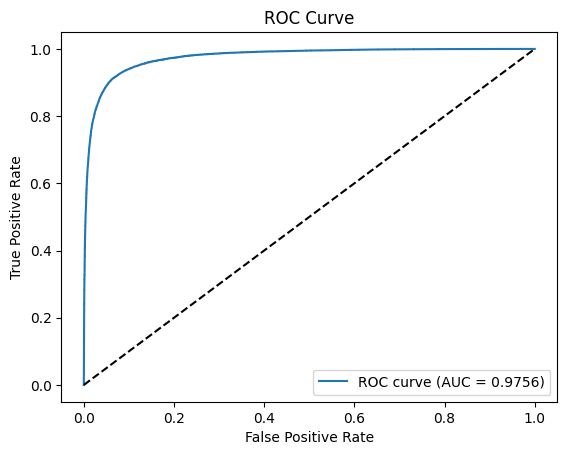

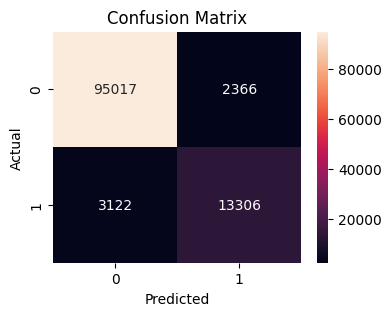

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Class prediction (0/1)
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Probability prediction (needed for ROC)
y_pred_prob = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.savefig('roc_curve.png')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')